# The gallery, live: held-out scoring through the public API

Every number in this notebook is produced by a live fit. Nothing here reads
`analysis/results/*.csv`.

The path is always the same four steps, and it is the whole point of the notebook:

```
gallery.fit(name, triangle, ...)          # a fitted GalleryEntry
  -> entry.log_lik_at(cells, field=...)   # ScoresHeldout  -> (draws, cells) log densities
  -> entry.predict_at(cells, field=...)   # PredictsHeldout -> (draws, cells) loss draws
  -> kernels.forecast.align_panel(...)    # one identical cell set per score
  -> gallery.leaderboard(panel)           # the board
```

`02_transformer_vs_statistical.ipynb` reads the published retrospectives and tells the
research story over 152 cohorts. This notebook does the opposite: a small panel, one
cutoff, one field, and every step executed in front of you so the API and the
milestone-6 leaderboard semantics are visible rather than described.

**What it costs.** About 20 minutes of fitting on the dev box, dominated by
`compartmental` (a hierarchical ODE-style model at relaxed sampler settings) and
`guszcza_growth_curve`. The per-family timings, and the measured total for the run
committed here, are printed in the last cell.

**What it is not.** 25 cohorts at one cutoff on one field is a demonstration, not a
study. The evidence lives in the 200-company retrospectives
(`scripts/meyers_validation.py`, `scripts/compare_gallery.py`) and in notebook 02. The
closing section says explicitly what this notebook does and does not claim.

In [1]:
import datetime as dt
import logging
import platform
import sys
import time
import warnings
from pathlib import Path

import ibis
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from cmdstanpy.utils import get_logger as cmdstan_logger
from matplotlib.patches import Patch

import ibnr
from ibnr import gallery
from ibnr.data.schedule_p import (
    active_mart_path,
    active_publish_id,
    load_schedule_p,
    pinned_source,
)
from ibnr.gallery.entry import PredictsHeldout, ScoresHeldout
from ibnr.kernels.calibration import ks_uniformity, pp_points
from ibnr.kernels.forecast import SCORE_DIRECTION, Absence, CohortForecast, align_panel
from ibnr.kernels.holdout import next_diagonal

warnings.filterwarnings("ignore")

# cmdstanpy installs its own INFO StreamHandler the first time a model is USED,
# which would override a level set at import time. Reaching for the logger
# through cmdstanpy's own accessor forces that setup to happen now, so the level
# sticks. Without this, guszcza_growth_curve and compartmental alone emit
# hundreds of init-rejection lines and the committed notebook is unreadable.
_lg = cmdstan_logger()
_lg.setLevel(logging.ERROR)
for _h in _lg.handlers:
    _h.setLevel(logging.ERROR)

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)

# --- switches ---------------------------------------------------------------
RUN_COMPARTMENTAL = True  # ~13-20 min; the only high-variance line item
RUN_REPORTED_APPENDIX = True  # ~3 min; meyers_ccl / meyers_csr on reported_loss

# --- the one cutoff, the one field ------------------------------------------
AS_OF = dt.date(1997, 12, 31)
FIELD = "paid_loss"
TASK = f"{FIELD}@1997"
PREMIUM_FIELD = "earned_premium"
# THE STUDY WINDOW. The triangle itself is cut to these accident years before
# anything is fitted, so every fit and every held-out cell rest on the same
# data - see "The study window" below. Accident years 1988 and 1989 are out of
# the study entirely; they are not merely left unscored.
ORIGINS = [dt.date(y, 1, 1) for y in range(1990, 1998)]
SEED_FIT = 11  # every sampler / bootstrap / torch init
SEED_DRAW = 7  # every predict_at() and predict() call

# --- provenance -------------------------------------------------------------
SOURCE = pinned_source()  # never resolves @latest, never calls gh
PUBLISH_ID = active_publish_id()
print("ibnr           ", ibnr.__version__)
print("python         ", sys.version.split()[0], platform.platform())
print("mart source    ", SOURCE)
print("mart publish_id", PUBLISH_ID)
print("mart parquet   ", active_mart_path(SOURCE).name)

C:\Users\EthanKang\Projects\ibnr\.claude\worktrees\agent-adcbfc5a4b9c7a23c\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ibnr            0.5.0
python          3.12.13 Windows-11-10.0.26200-SP0
mart source     github://EKtheSage/cas-schedule-p-data-model@20260613_041006
mart publish_id 20260613_041006
mart parquet    mart_reserving_model_training.parquet


## The panel

Two mechanical screens, both re-derived below from the mart rather than pasted in.

1. **The milestone-3 / Meyers screen** (`scripts/meyers_validation.select_companies`,
   the monograph's Table A.1): CV of net earned premium, CV of the net/direct premium
   ratio, a complete 10x10 square, a premium and loss floor, and Meyers' one excluded
   group. Run on all four lines it passes 60 companies on two or more lines - the 152
   `(company, line)` pairs the milestone-3 study scored.

2. **An ODP positivity screen.** `england_verrall_odp` legitimately refuses a cohort
   with a negative paid increment: the over-dispersed Poisson quasi-likelihood is not
   defined there. That is a documented family limit, not a bug. Of the 152 pairs only
   some are clean, and only **10 companies are clean on every one of their screened
   lines**. The screen reads the whole 1988-1997 history rather than the study
   window defined below: a cohort clean over ten accident years is clean over the
   eight the study keeps, so it is strictly conservative, and it keeps this panel
   identical to the one the published board ran on.

Selecting whole clean **companies** rather than clean **pairs** is deliberate. It keeps
ODP on the board with zero refusals, so every model is asked about exactly the same 25
cohorts (the cohort-data parity rule); and it leaves each company with two or more lines,
which is what the multiline appendix at the end needs.

The size range is wide on purpose: over the study window the largest cohort carries
about twelve million (USD thousands) of mean earned premium and the smallest a couple
of hundred, so the board is not a study of one magnitude.

In [2]:
# scripts/ is not an installed package, so the screen is imported by path rather
# than copied - a copy would drift from the script that produced the published
# retrospectives, and then the panel would silently stop being the study's panel.
REPO = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
sys.path.insert(0, str(REPO / "scripts"))
from meyers_validation import MEYERS_LINES, select_companies  # noqa: E402

MART = active_mart_path(SOURCE)

t0 = time.perf_counter()
passing = {ln: set(select_companies(MART, ln, 10_000)["company_code"]) for ln in MEYERS_LINES}
by_company: dict[str, list[str]] = {}
for ln, codes in passing.items():
    for c in codes:
        by_company.setdefault(c, []).append(ln)
multiline = {c: sorted(ls) for c, ls in by_company.items() if len(ls) >= 2}
print({ln: len(v) for ln, v in passing.items()})
print(
    f"companies passing on >=2 lines: {len(multiline)}  pairs: {sum(map(len, multiline.values()))}"
)

# --- ODP positivity screen on the <=1997 training slice ----------------------
# Deliberately over the FULL 1988-1997 history rather than the study window
# below. It is strictly conservative - a cohort with no negative paid increment
# over ten accident years has none over the eight the study keeps - and running
# it on the wider history is what keeps this panel identical to the one the
# published board used, so the two are comparable cohort for cohort.
scan = load_schedule_p(SOURCE, lines=MEYERS_LINES, companies=sorted(multiline)).expr.execute()
scan["eval_date"] = pd.to_datetime(scan["eval_date"])
scan["origin_period"] = pd.to_datetime(scan["origin_period"])
paid_train = scan[
    (scan["field"] == FIELD)
    & (scan["eval_date"] <= pd.Timestamp(AS_OF))
    & (scan["origin_period"].dt.year.between(1988, 1997))
]
clean_pairs = set()
for key, g in paid_train.groupby(["company_code", "line_of_business"]):
    increments = [
        np.diff(np.r_[0.0, gg.sort_values("dev_lag")["value"].to_numpy()])
        for _, gg in g.groupby("origin_period")
    ]
    if all((inc >= 0).all() for inc in increments):
        clean_pairs.add(key)
print(f"pairs with no negative paid increment in the training slice: {len(clean_pairs)}")

PANEL = {c: ls for c, ls in sorted(multiline.items()) if all((c, ln) in clean_pairs for ln in ls)}
COHORTS = [(c, ln) for c, ls in PANEL.items() for ln in ls]
LINES = sorted({ln for ls in PANEL.values() for ln in ls})
print(f"screens took {time.perf_counter() - t0:.1f}s")

# Recorded, so a future gold publish that moves the panel is LOUD rather than a
# board that silently compares different insurers to the published one.
EXPECTED_PANEL = {
    "10022": ["commercial_auto", "private_passenger_auto"],
    "14044": ["commercial_auto", "other_liability", "private_passenger_auto"],
    "1767": [
        "commercial_auto",
        "other_liability",
        "private_passenger_auto",
        "workers_compensation",
    ],
    "18767": ["commercial_auto", "workers_compensation"],
    "2003": ["other_liability", "private_passenger_auto"],
    "25275": ["commercial_auto", "private_passenger_auto"],
    "27022": ["commercial_auto", "private_passenger_auto"],
    "2712": ["commercial_auto", "workers_compensation"],
    "620": ["commercial_auto", "other_liability", "private_passenger_auto"],
    "7080": ["commercial_auto", "private_passenger_auto", "workers_compensation"],
}
assert PANEL == EXPECTED_PANEL, f"panel moved under publish_id {PUBLISH_ID}: {PANEL}"
print(f"\n{len(PANEL)} companies, {len(COHORTS)} cohorts, {len(LINES)} lines")
for c, ls in PANEL.items():
    print(f"  {c:>6}  {', '.join(ls)}")

{'commercial_auto': 63, 'private_passenger_auto': 60, 'workers_compensation': 52, 'other_liability': 56}
companies passing on >=2 lines: 60  pairs: 152


pairs with no negative paid increment in the training slice: 87
screens took 1.5s

10 companies, 25 cohorts, 4 lines
   10022  commercial_auto, private_passenger_auto
   14044  commercial_auto, other_liability, private_passenger_auto
    1767  commercial_auto, other_liability, private_passenger_auto, workers_compensation
   18767  commercial_auto, workers_compensation
    2003  other_liability, private_passenger_auto
   25275  commercial_auto, private_passenger_auto
   27022  commercial_auto, private_passenger_auto
    2712  commercial_auto, workers_compensation
     620  commercial_auto, other_liability, private_passenger_auto
    7080  commercial_auto, private_passenger_auto, workers_compensation


In [3]:
t0 = time.perf_counter()
tri_all = load_schedule_p(SOURCE, companies=list(PANEL), lines=LINES)

# load_schedule_p returns the cross product of companies x lines; keep only the
# 25 screened pairs.
_e = tri_all.expr
_keep = ibis.literal(False)
for c, ls in PANEL.items():
    for ln in ls:
        _keep = _keep | ((_e.company_code == c) & (_e.line_of_business == ln))
tri_full = tri_all.filter(_keep)

# API FRICTION, and the notebook does not work without it. The mart carries three
# segments (company_code, company_name, line_of_business) but kernels.nn_contract
# treats company_name as a display column and drops it, so a pooled NN fit is keyed
# on two. entry.log_lik_at(cells) then resolves the cohort from cells.frame[segments]
# and raises "unknown segment column 'company_name'". Binding the cohort explicitly
# does not rescue it either - index_into refuses 3 key columns against a 2-column
# fit one level down. Dropping the display column BEFORE both fit() and
# next_diagonal() is the only thing that works, and it costs the Stan entries
# nothing (they accept either schema).
tri_full = tri_full.with_expr(tri_full.expr.drop("company_name"))

# THE STUDY WINDOW, cut into the DATA and not into the scoring call. Everything
# downstream - every fit, every next_diagonal, every realized ultimate - reads
# `tri`, so "what the fits trained on" and "what the held-out census calls
# training" are the same table by construction instead of two arguments that
# have to be kept in agreement. `tri_full` survives only as the thing the window
# was cut from; nothing on the board reads it.
tri = tri_full.filter(tri_full.expr.origin_period.isin(ORIGINS))
print("segments:", tri.segments)
print(f"{tri_full.count()} rows loaded in {time.perf_counter() - t0:.1f}s")
assert sorted(tri.origins) == ORIGINS, sorted(tri.origins)
print(
    f"{tri.count()} rows inside the study window: accident years "
    f"{ORIGINS[0].year}-{ORIGINS[-1].year} ({len(ORIGINS)} of them)"
)

_frame = tri.expr.execute()
_frame["origin_period"] = pd.to_datetime(_frame["origin_period"])
# No year filter here any more: the triangle IS the window.
_prem = _frame[_frame["field"] == PREMIUM_FIELD]
_paid_latest = _frame[
    (_frame["field"] == FIELD) & (pd.to_datetime(_frame["eval_date"]) == pd.Timestamp(AS_OF))
]
pairs_table = (
    _prem.groupby(["company_code", "line_of_business"])["value"]
    .mean()
    .rename("mean_earned_premium")
    .to_frame()
    .join(
        _paid_latest.groupby(["company_code", "line_of_business"])["value"]
        .sum()
        .rename("paid_at_1997")
    )
    .reset_index()
    .sort_values("mean_earned_premium", ascending=False)
    .reset_index(drop=True)
)
print("\nunits:", tri.meta.units)
pairs_table.round(0)

segments: ['company_code', 'line_of_business']
35000 rows loaded in 0.1s


14000 rows inside the study window: accident years 1990-1997 (8 of them)

units: USD thousands


,company_code,line_of_business,mean_earned_premium,paid_at_1997
0,1767,private_passenger_auto,12635198.0,65271145.0
1,2003,private_passenger_auto,1897574.0,8778907.0
2,1767,commercial_auto,368564.0,1479179.0
3,1767,workers_compensation,315899.0,1162383.0
4,7080,workers_compensation,291281.0,1147580.0
5,1767,other_liability,264061.0,1150600.0
6,7080,private_passenger_auto,205590.0,805616.0
7,2712,workers_compensation,90936.0,351754.0
8,620,other_liability,77036.0,228301.0
9,2003,other_liability,71516.0,127602.0


## The held-out question

`kernels.holdout.next_diagonal(triangle, as_of=..., fields=...)` answers one question:
**given a fit trained on everything visible at `as_of`, which cells is it scored on?**
The answer is the next calendar diagonal, one cohort at a time, with the next
development lag `D_next` read from the data rather than assumed. Cells the fit could not
have known about are excluded and the reason is counted, not dropped silently
(`new_origin`, `dev_beyond_trained`, ...).

Two choices below are load-bearing.

**`fields=["paid_loss", "reported_loss"]` for every cohort, even though the board is on
paid.** `compartmental` is a joint paid-and-outstanding model and needs both. Mixing
one-field and two-field `HoldoutCells` on the same panel makes `align_panel` raise -
the second field contributes its own exclusions, so two models end up disagreeing about
the exclusion census for the same cohort, which is `align_panel`'s way of saying they
were not asked the same question. Building every cohort's cells **once** with both
fields and passing `field="paid_loss"` explicitly to `log_lik_at`, `predict_at` and
`CohortForecast` is what keeps the census identical. So `n_cells` reads 14 while the
paid narrowing gives 7, and that is correct.

**No `origins=` argument, because the triangle is already the study window.**
`next_diagonal` has one, and reaching for it here would be a mistake: it restricts the
*training* claims the census is computed from as well as the cells to be scored, so the
returned `HoldoutCells` would describe a training window narrower than the one the fits
actually consumed - `dev_beyond_trained` exclusions that no fit ever earned, and a
provenance claim that is not the fits'. Accident years 1988 and 1989 are instead cut out
of `tri` before anything is fitted. `HoldoutCells.train_origins` is asserted below
against `ORIGINS` for all 25 cohorts, so the census and the fits cannot drift apart.

**Why the window starts at 1990.** It is inherited from the earlier run of this notebook,
where scoring stopped at 1990 while the fits still saw 1988 - the mismatch this version
removes - and keeping the same eight accident years keeps the two boards comparable cell
for cell. Under a consistent window it buys nothing else, and the section after the fits
shows why: the deepest scored cell always sits at the fit's own development frontier, at
any window. So 1990 is now simply a study choice, and its cost - the two deepest
development lags, where a growth-curve or CSR-style model is most distinctive - is
caveat 5 in the closing section.

That leaves **7 held-out paid cells per cohort, 175 offered in total.** How many of those
each score actually rests on is decided later, by the intersection over that score's own
members - see "What the panel cost" below.


In [4]:
t0 = time.perf_counter()
sub: dict[tuple[str, str], object] = {}
cells: dict[tuple[str, str], object] = {}
for c, ln in COHORTS:
    s = tri.filter((tri.expr.company_code == c) & (tri.expr.line_of_business == ln))
    sub[(c, ln)] = s
    cells[(c, ln)] = next_diagonal(
        s,
        as_of=AS_OF,
        fields=[FIELD, "reported_loss"],  # both, so compartmental shares the census
        premium_field=PREMIUM_FIELD,
    )
print(f"25 x next_diagonal in {time.perf_counter() - t0:.1f}s")

_one = cells[COHORTS[0]]
print(
    f"\n{COHORTS[0]}: n_cells={_one.n_cells} (both fields), "
    f"paid={(_one.frame['field'] == FIELD).sum()}"
)
print("as_of      ", _one.as_of)
print("eval_date  ", _one.eval_date)
print("measure    ", _one.measure)
print("segments   ", _one.segments)
print("exclusions ", _one.exclusion_counts())

# THE PROVENANCE CHECK, and the reason this notebook was rebuilt. train_origins
# is what the held-out census believes the fit was trained on. It has to be the
# study window itself, on every cohort, or the board scores one training set and
# describes another.
assert all(list(v.train_origins) == ORIGINS for v in cells.values())
print("train_origins  ", f"{_one.train_origins[0]} .. {_one.train_origins[-1]}", "(all 25 cohorts)")

_counts = {k: int((v.frame["field"] == FIELD).sum()) for k, v in cells.items()}
print(
    "paid cells per cohort:", sorted(set(_counts.values())), "| panel total:", sum(_counts.values())
)
_one.frame[_one.frame["field"] == FIELD]

25 x next_diagonal in 10.5s

('10022', 'commercial_auto'): n_cells=14 (both fields), paid=7
as_of       1997-12-31
eval_date   1998-12-31
measure     cumulative
segments    ('company_code', 'line_of_business')
exclusions  {'new_origin': 0, 'dev_beyond_trained': 2, 'no_predecessor': 0}
train_origins   1990-01-01 .. 1997-01-01 (all 25 cohorts)
paid cells per cohort: [7] | panel total: 175


,company_code,line_of_business,field,origin_period,dev_lag,eval_date,value,prev_value,premium
0,10022,commercial_auto,paid_loss,1991-01-01,96,1998-12-31,792.0,790.0,1061.0
1,10022,commercial_auto,paid_loss,1992-01-01,84,1998-12-31,626.0,623.0,1281.0
2,10022,commercial_auto,paid_loss,1993-01-01,72,1998-12-31,861.0,852.0,1393.0
3,10022,commercial_auto,paid_loss,1994-01-01,60,1998-12-31,842.0,806.0,1692.0
4,10022,commercial_auto,paid_loss,1995-01-01,48,1998-12-31,410.0,386.0,1371.0
5,10022,commercial_auto,paid_loss,1996-01-01,36,1998-12-31,331.0,252.0,1360.0
6,10022,commercial_auto,paid_loss,1997-01-01,24,1998-12-31,468.0,276.0,1652.0


## The roster: who can be scored on what

Milestone 6 splits a forecast into **two independent capabilities**, and the split is the
reason this board can be honest about entries with very different shapes:

* `ScoresHeldout` -> `log_lik_at()` -> a normalized predictive **density** -> **ELPD**;
* `PredictsHeldout` -> `predict_at()` -> predictive **draws** -> **CRPS**.

An entry may have either, both, or neither, and the two are not redundant.
`england_verrall_odp` draws perfectly well but its over-dispersed Poisson
quasi-likelihood is only a density up to proportionality, so it has no ELPD ever.
`deterministic/mack`'s bootstrap has no stated observation model, same conclusion by a
different route. The roster below is built from the live registry, not typed out.

Three entries - `sur`, `copula_glm`, `nn_transformer_ml` - subclass **neither** mixin.
They cannot appear in either score column at all, so they get an ultimate-level appendix
at the end instead of a board row. That is a gap in the entries, not in the panel, and
the leaderboard would say so with the reason `scorer_not_implemented` if they were
handed to it.

In [5]:
roster = (
    pd.DataFrame(
        [
            {
                "entry": name,
                "family": cls.family,
                "density (ELPD)": issubclass(cls, ScoresHeldout),
                "draws (CRPS)": issubclass(cls, PredictsHeldout),
            }
            for name in gallery.list()
            for cls in [gallery.get(name)]
        ]
    )
    .sort_values(["family", "entry"])
    .reset_index(drop=True)
)
print(
    f"{len(roster)} registered entries; "
    f"{roster['density (ELPD)'].sum()} density, {roster['draws (CRPS)'].sum()} draws, "
    f"{(~roster['density (ELPD)'] & ~roster['draws (CRPS)']).sum()} neither"
)
roster

15 registered entries; 8 density, 12 draws, 3 neither


,entry,family,density (ELPD),draws (CRPS)
0,clark_growth_curve,bayesian,False,True
1,compartmental,bayesian,True,True
2,england_verrall_odp,bayesian,False,True
3,guszcza_growth_curve,bayesian,True,True
4,meyers_ccl,bayesian,True,True
5,meyers_csr,bayesian,True,True
6,mack,deterministic,False,True
7,deeptriangle,nn,True,True
8,mdn,nn,True,True
9,nn_transformer,nn,True,True


In [6]:
# The methods section, in one dict. Every entry on the board is fitted with
# exactly these arguments - nothing is tuned per cohort.
PER_COHORT_CONFIG = {
    "mack": dict(sigma_rule="mack", heldout_n_draws=10_000),
    "clark": dict(growth_curve="loglogistic", method="cape_cod"),
    "meyers_ccl": dict(seed=SEED_FIT, parallel_chains=4),
    "meyers_csr": dict(seed=SEED_FIT, parallel_chains=4),
    "england_verrall_odp": dict(seed=SEED_FIT, parallel_chains=4),
    "clark_growth_curve": dict(seed=SEED_FIT, parallel_chains=4, growth_curve="loglogistic"),
    # 4x1000 rather than the entry's 4x2500 default: the same estimand at a
    # smaller Monte Carlo budget, which saves ~7 min on this panel. min_ess_kish
    # on the board is what makes the cost of that visible.
    "guszcza_growth_curve": dict(
        seed=SEED_FIT, parallel_chains=4, iter_sampling=1000, iter_warmup=1000
    ),
}
# mack and clark are the two entries whose fit() takes NO seed - they are a
# deterministic estimator and an MLE, and the randomness is in predict()/predict_at().
COMPARTMENTAL_CONFIG = dict(
    variant="lognormal",  # the better-calibrated arm on paid in the milestone-4 retro
    seed=SEED_FIT,
    parallel_chains=4,
    iter_sampling=1000,
    iter_warmup=1000,
    # kernels.harness stage-1 relaxation, NOT the monograph's 0.99 / 15: worth
    # about 4x per cohort and documented as such in the model card.
    target_accept=0.9,
    max_treedepth=12,
)
# The NN entries fit ONCE, pooled over the whole 25-cohort panel, then predict per
# cohort. 120 epochs / 5 ensemble members is the demonstrative cut of the published
# study's 400 epochs - see the closing caveats.
NN_CONFIG = dict(max_epochs=120, patience=15, ensemble_size=5, n_draws=500)

pd.DataFrame(
    [{"entry": k, "how": "per cohort", "config": str(v)} for k, v in PER_COHORT_CONFIG.items()]
    + [{"entry": "compartmental", "how": "per cohort", "config": str(COMPARTMENTAL_CONFIG)}]
    + [
        {"entry": n, "how": "pooled fit", "config": str(NN_CONFIG)}
        for n in ["nn_transformer", "mdn", "resnet", "deeptriangle"]
    ]
)

,entry,how,config
0,mack,per cohort,"{'sigma_rule': 'mack', 'heldout_n_draws': 10000}"
1,clark,per cohort,"{'growth_curve': 'loglogistic', 'method': 'cap..."
2,meyers_ccl,per cohort,"{'seed': 11, 'parallel_chains': 4}"
3,meyers_csr,per cohort,"{'seed': 11, 'parallel_chains': 4}"
4,england_verrall_odp,per cohort,"{'seed': 11, 'parallel_chains': 4}"
5,clark_growth_curve,per cohort,"{'seed': 11, 'parallel_chains': 4, 'growth_cur..."
6,guszcza_growth_curve,per cohort,"{'seed': 11, 'parallel_chains': 4, 'iter_sampl..."
7,compartmental,per cohort,"{'variant': 'lognormal', 'seed': 11, 'parallel..."
8,nn_transformer,pooled fit,"{'max_epochs': 120, 'patience': 15, 'ensemble_..."
9,mdn,pooled fit,"{'max_epochs': 120, 'patience': 15, 'ensemble_..."


In [7]:
# Stan compilation is a one-off cost that has nothing to do with sampling speed,
# so it is paid here and timed separately. On a warm checkout this is ~0s; on a
# cold one it is a few minutes and the fit timings below stay honest either way.
compile_seconds = {}
for name in [
    "meyers_ccl",
    "meyers_csr",
    "england_verrall_odp",
    "clark_growth_curve",
    "guszcza_growth_curve",
    *(["compartmental"] if RUN_COMPARTMENTAL else []),
]:
    t0 = time.perf_counter()
    gallery.get(name).precompile()
    compile_seconds[name] = round(time.perf_counter() - t0, 1)
print("precompile seconds:", compile_seconds)

precompile seconds: {'meyers_ccl': 0.3, 'meyers_csr': 0.2, 'england_verrall_odp': 0.2, 'clark_growth_curve': 0.3, 'guszcza_growth_curve': 0.2, 'compartmental': 0.5}


### The helper

This is the API surface the notebook exists to show, so it is written out rather than
hidden in a module. Note `Absence`: a missing array is never a bare `None`, because the
board has to distinguish "this entry has no density, ever" from "this run refused this
cohort". The vocabulary is closed - `fit_failed`, `no_cell_sampler`,
`no_predictive_density`, `not_offered`, `scorer_not_implemented`, `scoring_refused` -
and free text raises.

In [8]:
refusals: list[dict] = []
point_rows: list[dict] = []


def forecast_for(name, entry, key, *, field=FIELD, task=TASK):
    """One fitted entry + one cohort's held-out cells -> one CohortForecast."""
    kw = {}

    if isinstance(entry, ScoresHeldout):
        try:
            kw["log_density"] = entry.log_lik_at(cells[key], field=field)
        except Exception as exc:
            refusals.append(dict(model=name, cohort=key, axis="density", error=repr(exc)[:200]))
            kw["density_absence"] = Absence("scoring_refused", f"{type(exc).__name__}: {exc}"[:150])
    else:
        # Permanent and about the ENTRY: the quasi-likelihood / bootstrap entries.
        kw["density_absence"] = Absence("no_predictive_density")

    if isinstance(entry, PredictsHeldout):
        try:
            kw["draws"] = entry.predict_at(cells[key], field=field, seed=SEED_DRAW)
        except Exception as exc:
            refusals.append(dict(model=name, cohort=key, axis="draws", error=repr(exc)[:200]))
            kw["draws_absence"] = Absence("scoring_refused", f"{type(exc).__name__}: {exc}"[:150])
    else:
        kw["draws_absence"] = Absence("no_cell_sampler")

    return CohortForecast(model=name, task=task, cells=cells[key], field=field, **kw)


def fit_or_absent(name, key, **kwargs):
    """gallery.fit, or a forecast that records why there is none.

    A fit that raises must not silently vanish: an absent model row reads as
    "not run", while `fit_failed` on both axes says what happened and drops the
    cohort from that score's panel for the models that share it.
    """
    try:
        return gallery.fit(name, sub[key], loss_field=FIELD, as_of=AS_OF, **kwargs), None
    except Exception as exc:
        refusals.append(dict(model=name, cohort=key, axis="fit", error=repr(exc)[:200]))
        return None, CohortForecast.unavailable(
            model=name,
            task=TASK,
            cells=cells[key],
            field=FIELD,
            density_reason="fit_failed",
            draws_reason="fit_failed",
            detail=f"{type(exc).__name__}: {exc}"[:150],
        )


def point_row(name, entry, key):
    """Ultimate-level point estimate vs the realized outcome, for the same fit.

    predict() targets are per origin plus a 'total' row; realized_ultimates()
    aligns to them from the FULL triangle and restricts to the origins the
    training slice actually had - the mart runs to 2007 and an unrestricted
    aggregate is silently ~2.4x inflated (a gotcha that has bitten this repo).
    """
    is_nn = gallery.get(name).family == "nn"
    seg = {"company_code": key[0], "line_of_business": key[1]}
    pred = entry.predict(segment=seg, seed=SEED_DRAW) if is_nn else entry.predict(seed=SEED_DRAW)
    outcome = (
        entry.realized_ultimates(sub[key], segment=seg)
        if is_nn
        else entry.realized_ultimates(sub[key])
    )
    labels = pred.targets["label"].astype(str).tolist()
    i = labels.index("total") if "total" in labels else len(labels) - 1
    mean = float(pred.mean()[i])
    actual = float(np.asarray(outcome, dtype=float)[i])
    return dict(
        model=name,
        company_code=key[0],
        line_of_business=key[1],
        predicted_ultimate=mean,
        realized_ultimate=actual,
        pct_error=100.0 * (mean - actual) / actual,
        outcome_pct=100.0 * float(pred.cdf(np.asarray(outcome, dtype=float))[i]),
    )


def record_point(name, entry, key):
    """point_row, but a refusal is recorded rather than ending the run."""
    try:
        point_rows.append(point_row(name, entry, key))
    except Exception as exc:
        refusals.append(dict(model=name, cohort=key, axis="ultimate", error=repr(exc)[:200]))

In [9]:
forecasts: list[CohortForecast] = []
fit_seconds: dict[str, float] = {}

for name, kwargs in PER_COHORT_CONFIG.items():
    t0 = time.perf_counter()
    for key in COHORTS:
        # Build the forecast and the point row INSIDE the loop, then drop the
        # entry: 175 live fits, each Stan one carrying a 10,000-draw
        # InferenceData, does not fit in memory.
        entry, absent = fit_or_absent(name, key, **kwargs)
        if entry is None:
            forecasts.append(absent)
            continue
        forecasts.append(forecast_for(name, entry, key))
        record_point(name, entry, key)
        del entry
    fit_seconds[name] = round(time.perf_counter() - t0, 1)
    print(
        f"{name:22s} {fit_seconds[name]:7.1f}s  "
        f"({fit_seconds[name] / len(COHORTS):.1f}s per cohort)",
        flush=True,
    )
print(f"\nrefusals so far: {len(refusals)}")
for r in refusals:
    print("  ", r)

mack                       4.5s  (0.2s per cohort)


clark                     12.1s  (0.5s per cohort)


meyers_ccl                57.6s  (2.3s per cohort)


meyers_csr                59.1s  (2.4s per cohort)


england_verrall_odp       45.3s  (1.8s per cohort)


clark_growth_curve        52.9s  (2.1s per cohort)


guszcza_growth_curve     178.4s  (7.1s per cohort)



refusals so far: 2
   {'model': 'clark', 'cohort': ('27022', 'commercial_auto'), 'axis': 'draws', 'error': "ValueError('lam value too large')"}
   {'model': 'clark', 'cohort': ('27022', 'commercial_auto'), 'axis': 'ultimate', 'error': "ValueError('lam value too large')"}


In [10]:
if RUN_COMPARTMENTAL:
    t0 = time.perf_counter()
    for i, key in enumerate(COHORTS, 1):
        t1 = time.perf_counter()
        entry, absent = fit_or_absent("compartmental", key, **COMPARTMENTAL_CONFIG)
        if entry is None:
            forecasts.append(absent)
        else:
            forecasts.append(forecast_for("compartmental", entry, key))
            record_point("compartmental", entry, key)
            del entry
        print(
            f"  [{i:2d}/{len(COHORTS)}] {key[0]:>6} {key[1]:<24} {time.perf_counter() - t1:6.1f}s",
            flush=True,
        )
    fit_seconds["compartmental"] = round(time.perf_counter() - t0, 1)
    print(
        f"\ncompartmental {fit_seconds['compartmental']:.1f}s "
        f"({fit_seconds['compartmental'] / len(COHORTS):.1f}s per cohort)"
    )
else:
    print("compartmental skipped (RUN_COMPARTMENTAL = False)")

  [ 1/25]  10022 commercial_auto            10.7s


  [ 2/25]  10022 private_passenger_auto     11.8s


  [ 3/25]  14044 commercial_auto             7.8s


  [ 4/25]  14044 other_liability            10.0s


  [ 5/25]  14044 private_passenger_auto     17.1s


...

  [22/25]    620 private_passenger_auto     11.0s


  [23/25]   7080 commercial_auto            16.3s


  [24/25]   7080 private_passenger_auto     33.1s


  [25/25]   7080 workers_compensation       20.9s



compartmental 462.9s (18.5s per cohort)


In [11]:
from ibnr.gallery.nn.deeptriangle import DeepTriangleConfig
from ibnr.gallery.nn.mdn import MDNConfig
from ibnr.gallery.nn.resnet import ResNetConfig
from ibnr.gallery.nn.transformer import TransformerConfig

# One pooled fit per entry over the WHOLE panel triangle, then 25 cohort
# forecasts off it. The cost therefore amortizes, and the clustering unit for
# any paired test on these rows is the FIT (the whole panel), not the cohort.
NN_ENTRIES = {
    "nn_transformer": TransformerConfig,
    "mdn": MDNConfig,
    "resnet": ResNetConfig,
    "deeptriangle": DeepTriangleConfig,
}
nn_fits = {}
for name, ConfigCls in NN_ENTRIES.items():
    t0 = time.perf_counter()
    entry = gallery.fit(
        name, tri, loss_field=FIELD, as_of=AS_OF, seed=SEED_FIT, config=ConfigCls(**NN_CONFIG)
    )
    t_fit = time.perf_counter() - t0
    for key in COHORTS:
        forecasts.append(forecast_for(name, entry, key))
        record_point(name, entry, key)
    fit_seconds[name] = round(time.perf_counter() - t0, 1)
    nn_fits[name] = entry
    print(
        f"{name:22s} {fit_seconds[name]:7.1f}s  (pooled fit {t_fit:.1f}s + "
        f"{fit_seconds[name] - t_fit:.1f}s scoring 25 cohorts)",
        flush=True,
    )

nn_transformer            98.4s  (pooled fit 87.6s + 10.8s scoring 25 cohorts)


mdn                       17.0s  (pooled fit 12.4s + 4.6s scoring 25 cohorts)


resnet                    55.4s  (pooled fit 50.0s + 5.4s scoring 25 cohorts)


deeptriangle              45.2s  (pooled fit 34.9s + 10.3s scoring 25 cohorts)


### The deepest scored cell is the fit's own frontier

All four NN entries refused a density on every cohort just now, and the reason is
structural rather than a fact about this panel.

The scored diagonal is the one immediately after the fit's training window, so its
deepest cell sits at exactly the deepest development lag the fit ever saw. Per cohort
that lag is reached by a single accident year on a single calendar diagonal - the latest
one - and the NN training scheme holds the latest diagonals out as the validation split
(`gallery/nn/_scheme.py::splits`, an eval_date split rather than a random one). So the
pooled per-development normalizer has **no** training context at that step, the step is
*pinned*, and `log_lik_at` refuses rather than scoring against an untrained head
(`norm_stats`; the v2 fix the model cards describe).

Moving the window does not escape it - the frontier moves with the window. The earlier
run avoided it only by scoring a diagonal two development steps shallower than the one
its fits were trained for, which is precisely the provenance mismatch this version
removes. The honest consequence is that the four NN entries have **no ELPD column on a
consistent panel**, and their ELPD rows in the earlier run should be read as an artefact
of that mismatch.

The cell below shows the three parts of that claim from this run: the refusal names the
pinned development step; the identical fits score a probe diagonal that stops one step
short of the frontier; and `predict_at` works at the pinned step throughout, which is
why the NN entries keep every CRPS cell they offer.


In [12]:
# 1. the refusal, read off this run rather than re-derived.
_nn_refused = [r for r in refusals if r["model"] in nn_fits and r["axis"] == "density"]
print(
    f"NN density refusals this run: {len(_nn_refused)} of {len(nn_fits) * len(COHORTS)} "
    f"(entry, cohort) pairs - i.e. every one"
)
print("  ", _nn_refused[0]["model"], "->", _nn_refused[0]["error"][:230])

# 2. a PROBE, not a study object: the same cohort's diagonal one accident year
#    shallower, so its deepest cell is a development step INSIDE the fits'
#    frontier. The fitted entries are untouched; only the cells change.
_s0 = sub[COHORTS[0]]
_probe = next_diagonal(
    _s0.filter(_s0.expr.origin_period.isin(ORIGINS[1:])),
    as_of=AS_OF,
    fields=[FIELD, "reported_loss"],
    premium_field=PREMIUM_FIELD,
)
_pf = cells[COHORTS[0]].frame
_panel_devs = sorted(_pf.loc[_pf["field"] == FIELD, "dev_lag"])
_probe_devs = sorted(_probe.frame.loc[_probe.frame["field"] == FIELD, "dev_lag"])
print(f"\n{COHORTS[0]} panel cells: dev_lags {_panel_devs}")
print(f"{' ' * len(str(COHORTS[0]))} probe cells: dev_lags {_probe_devs}")

# 3. all four, because the claim is about the whole NN family and the four heads
#    do not share a density implementation.
for _name, _fit in nn_fits.items():
    try:
        _ll = _fit.log_lik_at(_probe, field=FIELD)
        _verdict = f"probe density SCORED {_ll.shape}"
    except Exception as exc:
        _verdict = f"probe density ALSO refused: {type(exc).__name__}: {exc}"[:120]
    _draws = _fit.predict_at(cells[COHORTS[0]], field=FIELD, seed=SEED_DRAW)
    print(f"\n{_name}: {_verdict}")
    print(f"{' ' * len(_name)}  draws at the pinned frontier are fine: {_draws.shape}")

NN density refusals this run: 100 of 100 (entry, cohort) pairs - i.e. every one
   nn_transformer -> ValueError('1 cell(s) sit at pinned dev step(s) [8]: fewer than two training-context values reached the per-dev normalizer there, so the MDN head is untrained and its scale is degenerate. nn_transform



('10022', 'commercial_auto') panel cells: dev_lags [24, 36, 48, 60, 72, 84, 96]
                             probe cells: dev_lags [24, 36, 48, 60, 72, 84]

nn_transformer: probe density SCORED (5, 6)
                draws at the pinned frontier are fine: (500, 7)

mdn: probe density SCORED (5, 6)
     draws at the pinned frontier are fine: (500, 7)

resnet: probe density SCORED (5, 6)
        draws at the pinned frontier are fine: (500, 7)

deeptriangle: probe density SCORED (5, 6)
              draws at the pinned frontier are fine: (500, 7)


In [13]:
panel = align_panel(forecasts, units=tri.meta.units)
print(repr(panel))
print()
print(
    f"ELPD panel: {panel.n_cells_for('elpd'):4d} cells over "
    f"{panel.n_cohorts_for('elpd')} cohorts | members {list(panel.elpd_members)}"
)
print(f"            fingerprint {panel.elpd_fingerprint}")
print(
    f"CRPS panel: {panel.n_cells_for('crps'):4d} cells over "
    f"{panel.n_cohorts_for('crps')} cohorts | members {list(panel.crps_members)}"
)
print(f"            fingerprint {panel.crps_fingerprint}")
print(f"union of the two panels: {panel.n_cells} cells")

ForecastPanel(paid_loss@1997 @ 1997-12-31, 12 models, 24 cohorts | elpd: 126 cells over ['compartmental', 'guszcza_growth_curve', 'meyers_ccl', 'meyers_csr'] | crps: 168 cells over ['clark', 'clark_growth_curve', 'compartmental', 'deeptriangle', 'england_verrall_odp', 'guszcza_growth_curve', 'mack', 'mdn', 'meyers_ccl', 'meyers_csr', 'nn_transformer', 'resnet'] | dropped=56)

ELPD panel:  126 cells over 18 cohorts | members ['compartmental', 'guszcza_growth_curve', 'meyers_ccl', 'meyers_csr']
            fingerprint 0bd1e6212c5c56f2
CRPS panel:  168 cells over 24 cohorts | members ['clark', 'clark_growth_curve', 'compartmental', 'deeptriangle', 'england_verrall_odp', 'guszcza_growth_curve', 'mack', 'mdn', 'meyers_ccl', 'meyers_csr', 'nn_transformer', 'resnet']
            fingerprint 468d769145503ba4
union of the two panels: 168 cells


## How to read the board

* **ELPD is higher-is-better, CRPS is lower-is-better.** They point in opposite
  directions, which is why `SCORE_DIRECTION` is machine-readable and why `leaderboard()`
  has **no default sort and no `sort_by=`**: an average-rank column across two columns
  running opposite ways is nonsense, and the board refuses to invite one.
* **A missing score is `pd.NA`, never `0.0`.** On this board a pointwise ELPD is about
  -9 nats, so imputing 0 would credit a model that was never scored with more than the
  entire plausible gap between two real models - and 0.0 is simultaneously the best ELPD
  and the best CRPS there is. Every total is reduced in Python from the model's own
  array, because `groupby().sum()` over an all-missing group returns 0.0 in pandas.
* **The two columns can rest on different cells.** Each score's panel is the
  intersection over the models eligible for *that* score, so the board has
  `n_cells_elpd` and `n_cells_crps` and never a bare `n_cells`. Each column carries its
  own member list and its own fingerprint, stamped on every row: the number carries the
  set that produced it.
* **`elpd_status` says which kind of N/A this is.** `na: no_predictive_density` is
  permanent and about the entry (the ODP quasi-likelihood, the Mack bootstrap, the Clark
  MLE). `na: no_scored_cohorts` is this run: the four NN entries offered a density on no
  cohort at all, because every cohort's deepest scored cell is a pinned development step
  - see the section above. Both read as N/A on the board and they mean different things.
* **`n_cells_zero_density`** counts cells where every posterior draw gave the outcome
  zero density. Those propagate as `-inf` rather than being dropped - a model that
  assigned zero probability to something that happened should rank last, not escape.
* **`min_ess_kish`** is the effective number of draws behind the worst cell's density,
  and **`n_draws_density_min`** the raw draw count. It is what separates a lead from a
  tie, and here it dissolves one: `compartmental` tops the ELPD column by about 0.35
  nats per cell over `meyers_csr`, and `min_ess_kish` says its worst cell's density
  rests on **2** effective draws out of 4,000, against roughly 3,100 out of 10,000 for
  `meyers_csr` and `meyers_ccl`. Three orders of magnitude fewer. Read the top of that
  column as "not separated at this budget" rather than as a ranking.


In [14]:
board = gallery.leaderboard(panel)
view = board[
    [
        "model",
        "n_cohorts",
        "n_cells_elpd",
        "elpd",
        "elpd_per_cell",
        "elpd_status",
        "n_cells_zero_density",
        "min_ess_kish",
        "n_draws_density_min",
        "n_cells_crps",
        "crps",
        "crps_per_cell",
        "n_draws_sample_min",
    ]
].copy()
print("SCORE_DIRECTION:", SCORE_DIRECTION)
view.sort_values("crps_per_cell").round(3)

SCORE_DIRECTION: {'elpd': 'higher_is_better', 'elpd_per_cell': 'higher_is_better', 'crps': 'lower_is_better', 'crps_per_cell': 'lower_is_better'}


,model,n_cohorts,n_cells_elpd,elpd,elpd_per_cell,elpd_status,n_cells_zero_density,min_ess_kish,n_draws_density_min,n_cells_crps,crps,crps_per_cell,n_draws_sample_min
6,mack,24,126,<NA>,<NA>,na: no_predictive_density,<NA>,<NA>,<NA>,168,560523.035,3336.447,10000
4,england_verrall_odp,24,126,<NA>,<NA>,na: no_predictive_density,<NA>,<NA>,<NA>,168,628358.518,3740.229,10000
2,compartmental,24,126,-1125.788,-8.935,scored,0,1.982,4000,168,637264.285,3793.24,4000
9,meyers_csr,24,126,-1169.875,-9.285,scored,0,3096.037,10000,168,640914.816,3814.969,10000
3,deeptriangle,24,126,<NA>,<NA>,na: no_scored_cohorts,<NA>,<NA>,<NA>,168,740571.531,4408.164,500
11,resnet,24,126,<NA>,<NA>,na: no_scored_cohorts,<NA>,<NA>,<NA>,168,768079.3,4571.901,500
7,mdn,24,126,<NA>,<NA>,na: no_scored_cohorts,<NA>,<NA>,<NA>,168,921318.384,5484.038,500
8,meyers_ccl,24,126,-1176.555,-9.338,scored,0,3079.84,10000,168,955455.801,5687.237,10000
1,clark_growth_curve,24,126,<NA>,<NA>,na: no_predictive_density,<NA>,<NA>,<NA>,168,1191250.284,7090.775,10000
0,clark,24,126,<NA>,<NA>,na: no_predictive_density,<NA>,<NA>,<NA>,168,1195338.964,7115.113,10000


In [15]:
# The full board, including the member lists and fingerprints every published
# number has to carry.
board

,task,as_of,model,n_cohorts,elpd_members,elpd_fingerprint,n_cells_elpd,elpd,elpd_per_cell,elpd_status,n_cells_zero_density,min_ess_kish,crps_members,crps_fingerprint,n_cells_crps,crps,crps_per_cell,crps_status,n_draws_density_min,n_draws_sample_min,n_cells_elpd_own,n_cells_elpd_dropped,n_cells_crps_own,n_cells_crps_dropped
0,paid_loss@1997,1997-12-31,clark,24,"compartmental,guszcza_growth_curve,meyers_ccl,...",0bd1e6212c5c56f2,126,<NA>,<NA>,na: no_predictive_density,<NA>,<NA>,"clark,clark_growth_curve,compartmental,deeptri...",468d769145503ba4,168,1195338.964447,7115.112884,scored,<NA>,10000,0,0,168,0
1,paid_loss@1997,1997-12-31,clark_growth_curve,24,"compartmental,guszcza_growth_curve,meyers_ccl,...",0bd1e6212c5c56f2,126,<NA>,<NA>,na: no_predictive_density,<NA>,<NA>,"clark,clark_growth_curve,compartmental,deeptri...",468d769145503ba4,168,1191250.283609,7090.775498,scored,<NA>,10000,0,0,175,7
2,paid_loss@1997,1997-12-31,compartmental,24,"compartmental,guszcza_growth_curve,meyers_ccl,...",0bd1e6212c5c56f2,126,-1125.788246,-8.934827,scored,0,1.981614,"clark,clark_growth_curve,compartmental,deeptri...",468d769145503ba4,168,637264.284861,3793.239791,scored,4000,4000,126,0,175,7
3,paid_loss@1997,1997-12-31,deeptriangle,24,"compartmental,guszcza_growth_curve,meyers_ccl,...",0bd1e6212c5c56f2,126,<NA>,<NA>,na: no_scored_cohorts,<NA>,<NA>,"clark,clark_growth_curve,compartmental,deeptri...",468d769145503ba4,168,740571.530864,4408.163874,scored,<NA>,500,0,0,175,7
4,paid_loss@1997,1997-12-31,england_verrall_odp,24,"compartmental,guszcza_growth_curve,meyers_ccl,...",0bd1e6212c5c56f2,126,<NA>,<NA>,na: no_predictive_density,<NA>,<NA>,"clark,clark_growth_curve,compartmental,deeptri...",468d769145503ba4,168,628358.517814,3740.229273,scored,<NA>,10000,0,0,175,7
5,paid_loss@1997,1997-12-31,guszcza_growth_curve,24,"compartmental,guszcza_growth_curve,meyers_ccl,...",0bd1e6212c5c56f2,126,-1200.448089,-9.527366,scored,0,319.303412,"clark,clark_growth_curve,compartmental,deeptri...",468d769145503ba4,168,1961591.592472,11676.140431,scored,4000,4000,175,49,175,7
6,paid_loss@1997,1997-12-31,mack,24,"compartmental,guszcza_growth_curve,meyers_ccl,...",0bd1e6212c5c56f2,126,<NA>,<NA>,na: no_predictive_density,<NA>,<NA>,"clark,clark_growth_curve,compartmental,deeptri...",468d769145503ba4,168,560523.035198,3336.446638,scored,<NA>,10000,0,0,175,7
7,paid_loss@1997,1997-12-31,mdn,24,"compartmental,guszcza_growth_curve,meyers_ccl,...",0bd1e6212c5c56f2,126,<NA>,<NA>,na: no_scored_cohorts,<NA>,<NA>,"clark,clark_growth_curve,compartmental,deeptri...",468d769145503ba4,168,921318.384146,5484.038001,scored,<NA>,500,0,0,175,7
8,paid_loss@1997,1997-12-31,meyers_ccl,24,"compartmental,guszcza_growth_curve,meyers_ccl,...",0bd1e6212c5c56f2,126,-1176.555194,-9.33774,scored,0,3079.840057,"clark,clark_growth_curve,compartmental,deeptri...",468d769145503ba4,168,955455.801126,5687.236911,scored,10000,10000,175,49,175,7
9,paid_loss@1997,1997-12-31,meyers_csr,24,"compartmental,guszcza_growth_curve,meyers_ccl,...",0bd1e6212c5c56f2,126,-1169.874777,-9.28472,scored,0,3096.037004,"clark,clark_growth_curve,compartmental,deeptri...",468d769145503ba4,168,640914.815561,3814.96914,scored,10000,10000,175,49,175,7


## What the panel cost

`panel.dropped` names every cell a member offered and the panel could not use, and which
member lacked it. `panel.absences` is the census behind every N/A. `panel.coverage` says
what each model offered and what survived. This is the milestone-6 design working: a
member that refuses one cohort removes that cohort from **that score's** panel for every
other member of that score - and from that score only.

In [16]:
print("dropped cells:", len(panel.dropped))
if len(panel.dropped):
    display(panel.dropped.head(12))
    print("\ndropped by score:", panel.dropped["score"].value_counts().to_dict())

# Summarised, not listed: the NN density refusals alone are one per (entry, cohort),
# and a hundred near-identical lines would bury the two that are not.
print("\nrun-level refusals recorded by the helper:", len(refusals))
_ref = pd.DataFrame(refusals)
if len(_ref):
    _ref["error (truncated)"] = _ref["error"].str.slice(0, 70)
    display(
        _ref.groupby(["model", "axis", "error (truncated)"], as_index=False)
        .agg(cohorts=("cohort", "nunique"))
        .sort_values(["model", "axis"])
        .reset_index(drop=True)
    )
display(panel.coverage)
display(
    panel.absences.groupby(["model", "axis", "reason", "scope"], as_index=False).agg(
        cohorts=("cohort", "nunique"), cells=("n_cells", "sum")
    )
)
print("upstream exclusions (same for every model, by construction):")
display(panel.excluded.head(10))

dropped cells: 56


,score,task,as_of,company_code,line_of_business,field,origin_period,dev_lag,missing_from
0,elpd,paid_loss@1997,1997-12-31,10022,private_passenger_auto,paid_loss,1991-01-01,96,"(compartmental,)"
1,elpd,paid_loss@1997,1997-12-31,10022,private_passenger_auto,paid_loss,1992-01-01,84,"(compartmental,)"
2,elpd,paid_loss@1997,1997-12-31,10022,private_passenger_auto,paid_loss,1993-01-01,72,"(compartmental,)"
3,elpd,paid_loss@1997,1997-12-31,10022,private_passenger_auto,paid_loss,1994-01-01,60,"(compartmental,)"
4,elpd,paid_loss@1997,1997-12-31,10022,private_passenger_auto,paid_loss,1995-01-01,48,"(compartmental,)"
5,elpd,paid_loss@1997,1997-12-31,10022,private_passenger_auto,paid_loss,1996-01-01,36,"(compartmental,)"
6,elpd,paid_loss@1997,1997-12-31,10022,private_passenger_auto,paid_loss,1997-01-01,24,"(compartmental,)"
7,elpd,paid_loss@1997,1997-12-31,14044,commercial_auto,paid_loss,1991-01-01,96,"(compartmental,)"
8,elpd,paid_loss@1997,1997-12-31,14044,commercial_auto,paid_loss,1992-01-01,84,"(compartmental,)"
9,elpd,paid_loss@1997,1997-12-31,14044,commercial_auto,paid_loss,1993-01-01,72,"(compartmental,)"



dropped by score: {'elpd': 49, 'crps': 7}

run-level refusals recorded by the helper: 109


,model,axis,error (truncated),cohorts
0,clark,draws,ValueError('lam value too large'),1
1,clark,ultimate,ValueError('lam value too large'),1
2,compartmental,density,ValueError('1 cell(s) have a non-positive outs...,4
3,compartmental,density,ValueError('2 cell(s) have a non-positive outs...,3
4,deeptriangle,density,ValueError('1 cell(s) sit at pinned dev step(s...,25
5,mdn,density,ValueError('1 cell(s) sit at pinned dev step(s...,25
6,nn_transformer,density,ValueError('1 cell(s) sit at pinned dev step(s...,25
7,resnet,density,ValueError('1 cell(s) sit at pinned dev step(s...,25


,model,n_cohorts_offered,is_elpd_member,elpd_status,n_cohorts_elpd,n_cells_elpd_own,n_cells_elpd_on_panel,n_cells_elpd_dropped,is_crps_member,crps_status,n_cohorts_crps,n_cells_crps_own,n_cells_crps_on_panel,n_cells_crps_dropped
0,clark,25,False,na: no_predictive_density,0,0,0,0,True,scored,24,168,168,0
1,clark_growth_curve,25,False,na: no_predictive_density,0,0,0,0,True,scored,25,175,168,7
2,compartmental,25,True,scored,18,126,126,0,True,scored,25,175,168,7
3,deeptriangle,25,False,na: no_scored_cohorts,0,0,0,0,True,scored,25,175,168,7
4,england_verrall_odp,25,False,na: no_predictive_density,0,0,0,0,True,scored,25,175,168,7
5,guszcza_growth_curve,25,True,scored,25,175,126,49,True,scored,25,175,168,7
6,mack,25,False,na: no_predictive_density,0,0,0,0,True,scored,25,175,168,7
7,mdn,25,False,na: no_scored_cohorts,0,0,0,0,True,scored,25,175,168,7
8,meyers_ccl,25,True,scored,25,175,126,49,True,scored,25,175,168,7
9,meyers_csr,25,True,scored,25,175,126,49,True,scored,25,175,168,7


,model,axis,reason,scope,cohorts,cells
0,clark,density,no_predictive_density,model,25,175
1,clark,draws,scoring_refused,cohort,1,7
2,clark_growth_curve,density,no_predictive_density,model,25,175
3,compartmental,density,scoring_refused,cohort,7,49
4,deeptriangle,density,scoring_refused,cohort,25,175
5,england_verrall_odp,density,no_predictive_density,model,25,175
6,mack,density,no_predictive_density,model,25,175
7,mdn,density,scoring_refused,cohort,25,175
8,nn_transformer,density,scoring_refused,cohort,25,175
9,resnet,density,scoring_refused,cohort,25,175


upstream exclusions (same for every model, by construction):


,cohort,new_origin,dev_beyond_trained,no_predecessor,n_scorable
0,"(10022, commercial_auto)",0,2,0,7
1,"(10022, private_passenger_auto)",0,2,0,7
2,"(14044, commercial_auto)",0,2,0,7
3,"(14044, other_liability)",0,2,0,7
4,"(14044, private_passenger_auto)",0,2,0,7
5,"(1767, commercial_auto)",0,2,0,7
6,"(1767, other_liability)",0,2,0,7
7,"(1767, private_passenger_auto)",0,2,0,7
8,"(1767, workers_compensation)",0,2,0,7
9,"(18767, commercial_auto)",0,2,0,7


## Per cohort, and whether one cohort is driving the ranking

`panel.by_cohort` is one row per (model, cohort). Paired differences against a single
reference model are the honest way to read it: a leaderboard total is extensive, so a
model that happens to be good on the two biggest cohorts wins the sum outright.

The table is the ELPD column, so it holds only the entries with a density on this panel -
the four MCMC entries. The NN entries are missing for the structural reason demonstrated
above, not because they scored badly.

Two things the panel object cannot enforce, and the sign test inherits both. The 25
cohorts are 10 companies, so cohorts of one company share its case-reserving practice and
its calendar-year effects - these are not 25 independent triangles. And a
paired-by-cohort reading is meaningful here only because every model in this table is
fitted per cohort; it would not be for a pooled fit, whose clustering unit is the fit
rather than the cohort. So read the p-values as a description of this board, not as an
inferential claim about the entries.


In [17]:
from scipy.stats import binomtest

REFERENCE = "meyers_csr"
bc = panel.by_cohort.copy()
bc["cohort"] = bc["cohort"].map(lambda t: f"{t[0]}/{t[1][:16]}")
# by_cohort carries pd.NA for "this model has no score here", so the column is
# object dtype - coerce for the pivot, but to NaN and never to 0.0.
bc["elpd"] = pd.to_numeric(bc["elpd"], errors="coerce")
wide = bc.pivot_table(index="cohort", columns="model", values="elpd", dropna=False)
wide = wide.dropna(axis=1, how="all")
display(wide.round(1))

diff = wide.sub(wide[REFERENCE], axis=0).drop(columns=[REFERENCE])
summary = pd.DataFrame(
    {
        "mean_elpd_diff": diff.mean(),
        "median_elpd_diff": diff.median(),
        "cohorts_better": (diff > 0).sum(),
        "cohorts_worse": (diff < 0).sum(),
        "worst_single_cohort": diff.min(),
        "best_single_cohort": diff.max(),
    }
)
summary["sign_test_p"] = [
    binomtest(int((diff[c] > 0).sum()), int(diff[c].notna().sum())).pvalue for c in diff.columns
]
print(f"pointwise ELPD difference vs {REFERENCE}, per cohort (positive = better than {REFERENCE})")
summary.round(3)

model,compartmental,guszcza_growth_curve,meyers_ccl,meyers_csr
cohort,,,,
10022/commercial_auto,-28.8,-41.8,-43.3,-43.1
10022/private_passenge,NaN,NaN,NaN,NaN
14044/commercial_auto,NaN,NaN,NaN,NaN
14044/other_liability,NaN,NaN,NaN,NaN
14044/private_passenge,NaN,NaN,NaN,NaN
1767/commercial_auto,-72.4,-72.5,-69.4,-68.2
1767/other_liability,-69.8,-81.3,-79.2,-78.3
1767/private_passenge,-83.2,-99.0,-93.3,-91.2
1767/workers_compensa,-65.5,-73.7,-69.2,-69.0


pointwise ELPD difference vs meyers_csr, per cohort (positive = better than meyers_csr)


,mean_elpd_diff,median_elpd_diff,cohorts_better,cohorts_worse,worst_single_cohort,best_single_cohort,sign_test_p
model,,,,,,,
compartmental,2.449,4.179,15,3,-33.192,14.325,0.008
guszcza_growth_curve,-1.699,-0.803,5,13,-10.896,2.318,0.096
meyers_ccl,-0.371,-0.190,7,11,-3.033,0.924,0.481


## Ultimate-level point estimates

The held-out board scores one diagonal. A reserving audience also wants the number the
model actually delivers: the predicted ultimate against what the later statements
revealed. Every row below comes from `entry.predict()` and `entry.realized_ultimates()`
on the same fits used above - `realized_ultimates` restricts to the origins the training
slice had, which on this study window is 1990-1997, and that is what keeps the mart's
later accident years out of the aggregate.

This is the one table where the four NN entries stand beside the per-cohort entries, so
it is also where the information asymmetry bites hardest: each NN row is a single fit
pooled over all 25 cohorts and reaches its number having seen roughly 25 times the loss
history of the rows next to it. Caveat 7 in the closing section spells out what that
costs the comparison.


In [18]:
points = pd.DataFrame(point_rows)
totals = points.groupby("model")[["predicted_ultimate", "realized_ultimate"]].sum()
per_model = points.groupby("model").agg(
    cohorts=("pct_error", "size"),
    median_pct_error=("pct_error", "median"),
    mean_abs_pct_error=("pct_error", lambda s: s.abs().mean()),
    median_outcome_pct=("outcome_pct", "median"),
)
# Aggregate error over the panel as a whole - dollar-weighted, so it is the
# number a reserving audience reads, and it is NOT the mean of the per-cohort
# percentage errors.
per_model["aggregate_pct_error"] = 100.0 * (
    totals["predicted_ultimate"] / totals["realized_ultimate"] - 1.0
)
display(per_model.sort_values("mean_abs_pct_error").round(2))
# Each aggregate row sums that model's OWN panel, so the rows are not all over the
# same dollars - derived from this run's refusals rather than written down, because a
# sentence naming a cohort goes stale the moment a fit behaves differently.
print(
    "aggregate_pct_error is per model, over the cohorts that model produced an ultimate "
    "for, so the rows are not all over the same dollars."
)
for _m, _n in per_model.loc[per_model["cohorts"] < len(COHORTS), "cohorts"].items():
    _missed = sorted(r["cohort"] for r in refusals if r["model"] == _m and r["axis"] == "ultimate")
    print(
        f"  {_m}: {int(_n)} of {len(COHORTS)} cohorts - predict() refused {_missed}, so those "
        "dollars are out of both its numerator and its denominator."
    )
display(
    points.pivot_table(
        index="line_of_business", columns="model", values="pct_error", aggfunc="median"
    ).round(1)
)

,cohorts,median_pct_error,mean_abs_pct_error,median_outcome_pct,aggregate_pct_error
model,,,,,
compartmental,25,0.79,3.72,27.62,0.75
deeptriangle,25,-0.26,4.53,56.40,1.30
resnet,25,2.84,5.21,29.60,5.12
mack,25,1.72,5.24,24.31,1.13
mdn,25,3.07,5.73,15.00,4.87
england_verrall_odp,25,1.85,6.58,13.44,1.20
clark,24,5.13,6.74,3.42,4.26
clark_growth_curve,25,5.42,7.02,0.17,4.38
nn_transformer,25,4.12,7.35,20.00,8.81


aggregate_pct_error is per model, over the cohorts that model produced an ultimate for, so the rows are not all over the same dollars.
  clark: 24 of 25 cohorts - predict() refused [('27022', 'commercial_auto')], so those dollars are out of both its numerator and its denominator.


model,clark,clark_growth_curve,compartmental,deeptriangle,england_verrall_odp,guszcza_growth_curve,mack,mdn,meyers_ccl,meyers_csr,nn_transformer,resnet
line_of_business,,,,,,,,,,,,
commercial_auto,5.8,5.6,0.6,-3.0,10.0,11.4,8.9,2.9,7.3,8.9,5.8,4.0
other_liability,0.4,2.6,-6.7,-13.3,0.0,12.2,-1.8,-6.2,13.2,4.3,-8.8,-5.0
private_passenger_auto,4.1,4.2,1.1,0.5,1.1,4.7,0.7,5.7,1.9,-0.2,5.4,4.4
workers_compensation,7.6,7.9,2.7,1.0,2.1,2.5,2.0,3.6,2.1,-0.4,1.2,2.2


## Calibration on the held-out cells

The PIT of a held-out cell is the fraction of predictive draws at or below the outcome.
If the predictive distribution is right, PITs are Uniform(0, 1), and `ks_uniformity` is
the two-sided KS test the Meyers retrospectives report (`D x 100`, with an asterisk when
it fails at 5%).

**The 5% band assumes independent observations and these cells are not independent.**
Three dependences, all of them real on this panel:

1. the 7 cells of a cohort come from one posterior over one triangle, and they are
   consecutive development lags of neighbouring accident years;
2. the 25 cohorts are 10 companies, so cohorts sharing a company share its case-reserving
   practice and its calendar-year effects;
3. the four NN rows are **one pooled fit each**, so all 168 of their cells come from a
   single estimation.

Under positive dependence the effective number of observations is smaller than `n`, the
null distribution of `D` is wider than `1.36/sqrt(n)`, and a test at that band
over-rejects. The cell-level table below is therefore **descriptive**: the statistic and
the p-p curve, with no critical value and no pass/fail column. It says which models are
further from uniform on this panel; it does not say that any of them is rejected.

**The calibrated test runs one level up.** `predict_at` returns *joint* draws - each row
is one posterior draw across all of a cohort's cells at once - so summing within a draw
gives the predictive distribution of that cohort's whole next diagonal, and the PIT of
the realized total is **one observation per cohort**. Dependence 1 is integrated out
exactly rather than adjusted for, and dependence 3 stops mattering for the null because
every model is now tested on one observation per cohort. What survives is dependence 2:
the cohorts of one company are still correlated, so these are near-independent and not
independent, and the residual is disclosed rather than corrected - 10 companies is far
too few blocks to bootstrap. The `n` is small enough that the test has little power
against anything short of gross miscalibration, which is the honest state of a 25-cohort
demonstration.

**What it finds, so the reader is not left to infer it.** One entry survives at 5% -
`meyers_csr`, D = 27.0 against a critical 27.8, p = 0.06 - and eleven do not. And every
model's mean cohort PIT sits well below 0.5 (0.13 to 0.40): the realized next-diagonal
total lands in the lower tail of the predictive far more often than it should. On a test
with this little power that is not a marginal signal - the cohort-total predictives are
biased high relative to their own spread, right across the gallery, and the per-cell mean
PITs above say the same thing more quietly. What the test cannot do is rank the eleven
failures against each other.


In [19]:
crps_keys = set(panel.cells.loc[panel.cells["on_crps_panel"], "key"])
collected: dict[str, list[np.ndarray]] = {}
cohort_pit_rows: list[dict] = []
for f in forecasts:
    if not f.has_draws:
        continue
    values = f.key_frame["value"].to_numpy(dtype=float)
    p = (f.draws <= values[None, :]).mean(axis=0)  # empirical predictive CDF at the outcome
    on = np.array([k in crps_keys for k in f.keys])
    if not on.any():  # the whole cohort fell off the CRPS panel
        continue
    collected.setdefault(f.model, []).append(p[on])
    # ONE PIT per cohort, off the SAME draws: sum the panel's cells within each
    # draw first, so the cohort's joint predictive of its next-diagonal total is
    # what gets tested and the within-cohort dependence is integrated out.
    totals = f.draws[:, on].sum(axis=1)
    cohort_pit_rows.append(
        dict(model=f.model, cohort=f.cohort, pit=float((totals <= values[on].sum()).mean()))
    )
pits = {m: np.concatenate(v) for m, v in collected.items()}

ks = (
    pd.DataFrame(
        [
            {"model": m, "n_cells": r.n, "D x 100": 100 * r.statistic, "mean_pit": float(p.mean())}
            for m, p in pits.items()
            for r in [ks_uniformity(p)]
        ]
    )
    .sort_values("D x 100")
    .reset_index(drop=True)
)
print(
    "DESCRIPTIVE - no critical value, no pass/fail. These cells are not independent\n"
    "(7 per cohort from one posterior, 25 cohorts over 10 companies, the four NN rows\n"
    "one pooled fit each), so the 1.36/sqrt(n) band does not hold. Calibrated test below."
)
ks.round(3)

DESCRIPTIVE - no critical value, no pass/fail. These cells are not independent
(7 per cohort from one posterior, 25 cohorts over 10 companies, the four NN rows
one pooled fit each), so the 1.36/sqrt(n) band does not hold. Calibrated test below.


,model,n_cells,D x 100,mean_pit
0,england_verrall_odp,168,11.440,0.445
1,mack,168,14.596,0.442
2,compartmental,168,16.369,0.424
3,deeptriangle,168,16.395,0.418
4,nn_transformer,168,16.762,0.408
5,resnet,168,18.419,0.397
6,mdn,168,18.471,0.393
7,meyers_csr,168,19.530,0.495
8,guszcza_growth_curve,168,23.194,0.348
9,meyers_ccl,168,23.247,0.455


In [20]:
cohort_pits = pd.DataFrame(cohort_pit_rows)
ks_cohort = (
    pd.DataFrame(
        [
            {
                "model": m,
                "n_cohorts": r.n,
                "D x 100": 100 * r.statistic,
                "critical 5% x 100": 100 * r.critical_value_5pct,
                "p_value": r.p_value,
                "passes": not r.reject_5pct,
                "mean_pit": float(g["pit"].mean()),
            }
            for m, g in cohort_pits.groupby("model")
            for r in [ks_uniformity(g["pit"].to_numpy())]
        ]
    )
    .sort_values("D x 100")
    .reset_index(drop=True)
)
# Every model tested on the SAME cohorts, or the D values are not comparable and the
# shared critical value is not shared. The CRPS panel is what guarantees it.
_n = sorted(set(ks_cohort["n_cohorts"]))
assert len(_n) == 1, ks_cohort
_companies = cohort_pits["cohort"].map(lambda c: c[0]).nunique()
print(
    f"one PIT per cohort, from that cohort's joint next-diagonal total: n = {_n[0]} "
    f"cohorts over {_companies} companies,\ncritical value "
    f"{ks_cohort['critical 5% x 100'].iloc[0]:.1f}. Cohorts of one company "
    "still share its reserving practice, so these are\nnear-independent rather than "
    f"independent; and at n = {_n[0]} the test only sees gross miscalibration."
)
ks_cohort.round(3)

one PIT per cohort, from that cohort's joint next-diagonal total: n = 24 cohorts over 10 companies,
critical value 27.8. Cohorts of one company still share its reserving practice, so these are
near-independent rather than independent; and at n = 24 the test only sees gross miscalibration.


,model,n_cohorts,D x 100,critical 5% x 100,p_value,passes,mean_pit
0,meyers_csr,24,27.030,27.761,0.060,True,0.403
1,nn_transformer,24,30.433,27.761,0.023,False,0.313
2,resnet,24,37.267,27.761,0.003,False,0.274
3,deeptriangle,24,38.500,27.761,0.002,False,0.296
4,mdn,24,42.067,27.761,0.000,False,0.247
5,meyers_ccl,24,48.143,27.761,0.000,False,0.289
6,compartmental,24,48.958,27.761,0.000,False,0.254
7,mack,24,51.947,27.761,0.000,False,0.207
8,guszcza_growth_curve,24,53.908,27.761,0.000,False,0.182
9,england_verrall_odp,24,54.393,27.761,0.000,False,0.187


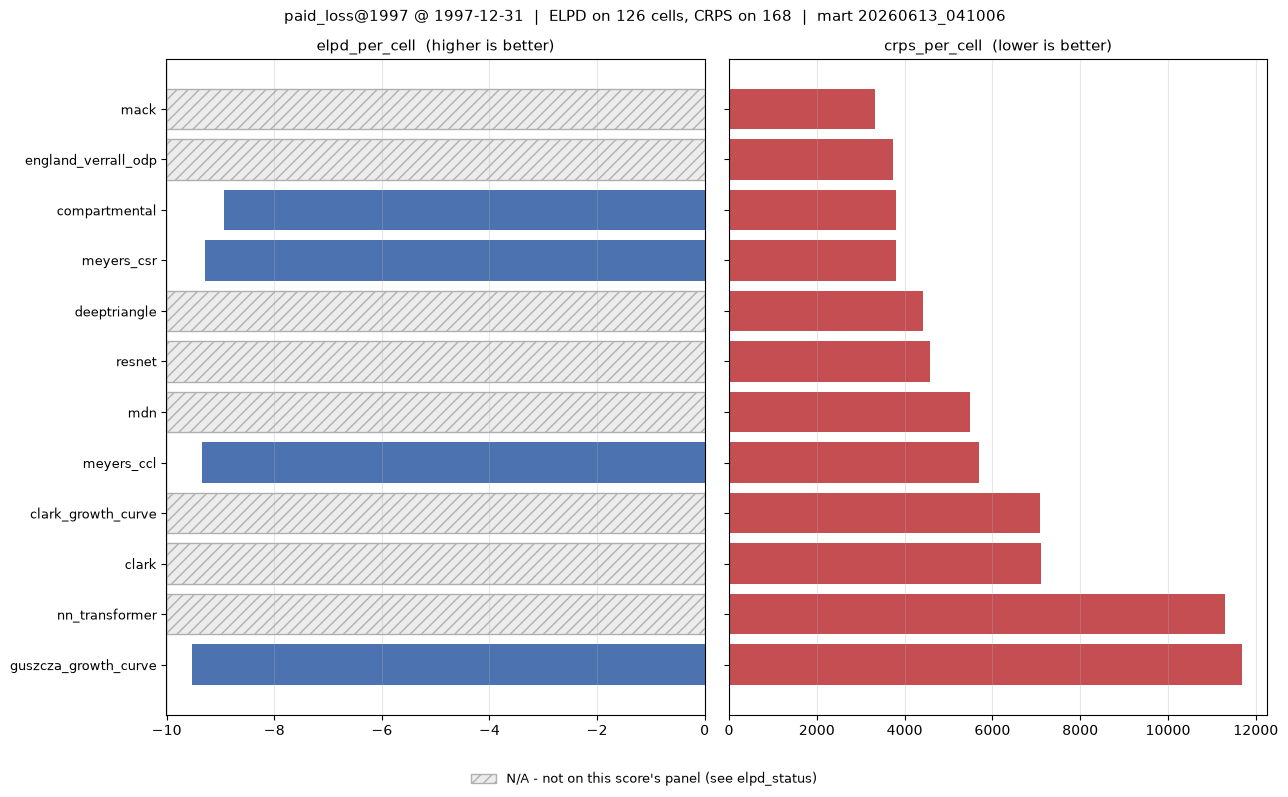

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 0.45 * len(board) + 2.6), sharey=True)
order = board.sort_values("crps_per_cell")["model"].tolist()
y = np.arange(len(order))

for ax, col, direction in zip(
    axes, ["elpd_per_cell", "crps_per_cell"], ["higher is better", "lower is better"]
):
    vals = board.set_index("model").loc[order, col]
    have = vals.notna().to_numpy()
    v = pd.to_numeric(vals, errors="coerce").to_numpy(dtype=float)
    ax.barh(y[have], v[have], color="#4c72b0" if col.startswith("elpd") else "#c44e52")
    if (~have).any():
        # N/A is drawn as an explicit hatched band, never omitted and never plotted as
        # 0: 0 is the best value in BOTH columns. It spans the WHOLE row - a band the
        # width of the data would read as a bar with a value - and it is named once in
        # the figure legend, because per-row text was wider than the band and printed
        # over the y tick labels.
        x0, x1 = ax.get_xlim()
        for j, yy in enumerate(y[~have]):
            ax.barh(
                yy,
                x1 - x0,
                left=x0,
                color="#ececec",
                edgecolor="#b0b0b0",
                hatch="///",
                label="N/A - not on this score's panel (see elpd_status)"
                if j == 0
                else "_nolegend_",
            )
        ax.set_xlim(x0, x1)
    ax.set_yticks(y, order, fontsize=9)
    ax.set_title(f"{col}  ({direction})", fontsize=11)
    ax.axvline(0, color="black", lw=0.6)
    ax.grid(axis="x", alpha=0.3)
axes[0].invert_yaxis()
_handles, _labels = axes[0].get_legend_handles_labels()
if _handles:
    fig.legend(_handles[:1], _labels[:1], loc="lower center", frameon=False, fontsize=9)
fig.suptitle(
    f"{TASK} @ {panel.as_of}  |  ELPD on {panel.n_cells_for('elpd')} cells, "
    f"CRPS on {panel.n_cells_for('crps')}  |  mart {PUBLISH_ID}",
    fontsize=11,
)
fig.tight_layout(rect=(0, 0.05, 1, 1))
plt.show()

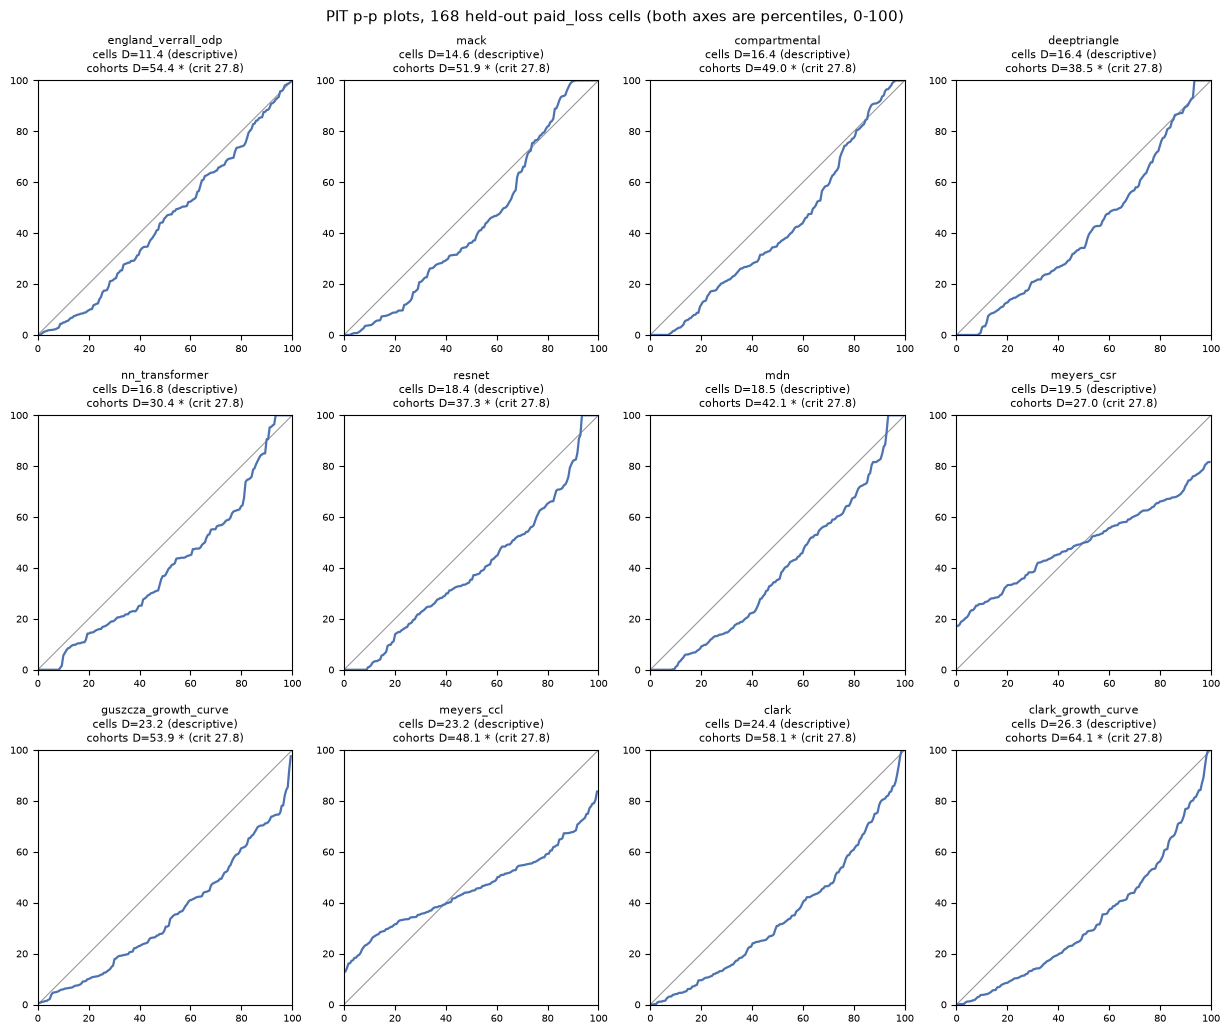

12 panels, [168] points each, on 0-100 axes


In [22]:
# pp_points returns PERCENTILES - (expected * 100, sorted PIT * 100), the Meyers
# convention the published retrospectives print. So the axes and the reference
# diagonal run 0-100 as well. Drawn against a [0, 1] diagonal with xlim/ylim (0, 1),
# every one of these points falls outside the window and the visible line is a
# clipping artifact, not the curve.
#
# The curves are the CELL-level PITs and are descriptive; the asterisk in each
# title is the COHORT-level test, which is the one with a valid null.
models = ks.sort_values("D x 100")["model"].tolist()
ncol = 4
nrow = int(np.ceil(len(models) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(3.1 * ncol, 3.5 * nrow), squeeze=False)
n_points = {}
_kc = ks_cohort.set_index("model")
for ax, m in zip(axes.ravel(), models):
    x, y = pp_points(pits[m])
    n_points[m] = len(x)
    ax.plot([0, 100], [0, 100], color="#999999", lw=0.8)
    ax.plot(x, y, lw=1.6, color="#4c72b0")
    r = ks.set_index("model").loc[m]
    rc = _kc.loc[m]
    flag = "" if rc["passes"] else " *"
    ax.set_title(
        f"{m}\ncells D={r['D x 100']:.1f} (descriptive)\n"
        f"cohorts D={rc['D x 100']:.1f}{flag} (crit {rc['critical 5% x 100']:.1f})",
        fontsize=8,
    )
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    ax.set_aspect("equal")
    ax.tick_params(labelsize=7)
for ax in axes.ravel()[len(models) :]:
    ax.axis("off")
fig.suptitle(
    f"PIT p-p plots, {panel.n_cells_for('crps')} held-out {FIELD} cells "
    "(both axes are percentiles, 0-100)",
    fontsize=11,
)
fig.tight_layout()
plt.show()

# The panels contain their data, and this is what says so rather than the eye.
assert set(n_points.values()) == {panel.n_cells_for("crps")}, n_points
print(f"{len(n_points)} panels, {sorted(set(n_points.values()))} points each, on 0-100 axes")

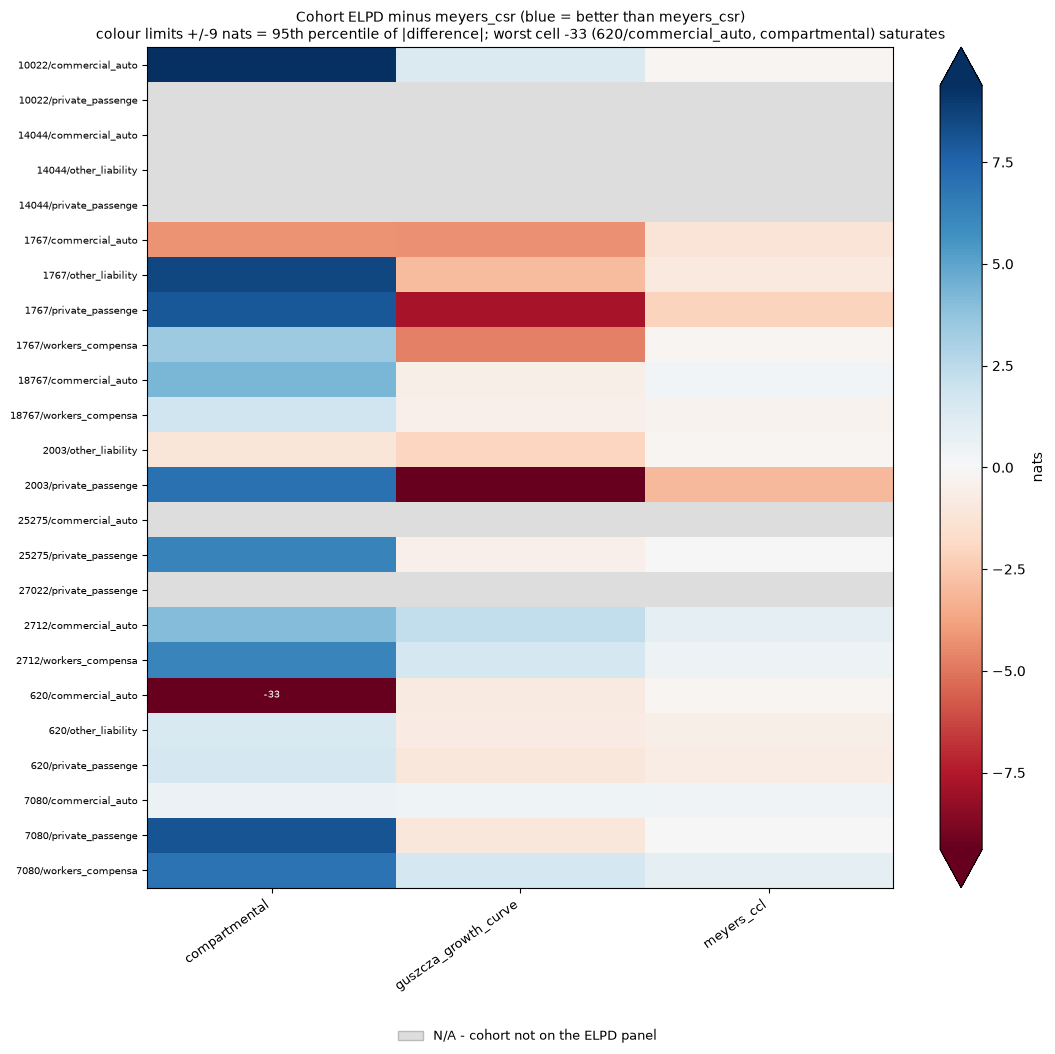

In [23]:
fig, ax = plt.subplots(figsize=(11, 0.34 * len(diff) + 2.4))
data = diff[sorted(diff.columns)]
arr = data.to_numpy(dtype=float)

# NaN here means "this cohort is not on the ELPD panel at all" (compartmental refused
# it), which is NOT a zero difference - so it gets its own grey instead of the
# diverging colormap's white, which is exactly what zero looks like.
cmap = plt.get_cmap("RdBu").with_extremes(bad="#dddddd")
# Robust limits. The worst single cell is about 3x the next worst, and symmetric
# limits off nanmax(|.|) pushed every other cohort to near-white. Anything past the
# limit saturates, and the extreme is labelled on its own cell so it is not lost.
lim = float(np.nanpercentile(np.abs(arr), 95))
im = ax.imshow(arr, aspect="auto", cmap=cmap, vmin=-lim, vmax=lim)
_r, _c = np.unravel_index(np.nanargmin(arr), arr.shape)
ax.text(_c, _r, f"{arr[_r, _c]:.0f}", ha="center", va="center", fontsize=7, color="white")
ax.set_xticks(range(data.shape[1]), data.columns, rotation=35, ha="right", fontsize=9)
ax.set_yticks(range(data.shape[0]), data.index, fontsize=7)
ax.set_title(
    f"Cohort ELPD minus {REFERENCE} (blue = better than {REFERENCE})\n"
    f"colour limits +/-{lim:.0f} nats = 95th percentile of |difference|; "
    f"worst cell {arr[_r, _c]:.0f} ({data.index[_r]}, {data.columns[_c]}) saturates",
    fontsize=10,
)
fig.colorbar(im, ax=ax, label="nats", extend="both")
fig.legend(
    handles=[
        Patch(
            facecolor="#dddddd",
            edgecolor="#bbbbbb",
            label="N/A - cohort not on the ELPD panel",
        )
    ],
    loc="lower center",
    frameon=False,
    fontsize=9,
)
fig.tight_layout(rect=(0, 0.04, 1, 1))
plt.show()

## Appendix A: the multiline entries

`sur`, `copula_glm` and `nn_transformer_ml` subclass **neither** held-out mixin, so they
cannot appear in the ELPD or CRPS column at all. They are the entries that model
dependence *across lines*, which is the one thing every model on the board above
structurally cannot do - the single-line transformer's per-line draws are independent -
so they are compared here at the ultimate level instead, one fit per company over that
company's screened lines.

`nn_transformer_ml` is omitted on cost: its autoregressive rollout samples line by line
per calendar diagonal, and a single pooled fit on this 10-company panel ran past 10
minutes without completing when that was measured. It is the one cost in this notebook
quoted from a separate measurement rather than from the timing table at the end. Its
published results are in notebook 02 and in `analysis/results/compare_gallery*.csv`.

In [24]:
ml_rows, corr_rows, ml_failures = [], [], []
t0 = time.perf_counter()
for company, lines in PANEL.items():
    ce = tri.expr
    ctri = tri.filter(ce.company_code == company)
    for name, kwargs in [("sur", {}), ("copula_glm", dict(dev_effect="factor"))]:
        try:
            entry = gallery.fit(name, ctri, loss_field=FIELD, as_of=AS_OF, **kwargs)
        except Exception as exc:
            # sur's FGLS and copula_glm's bootstrap each have documented family
            # limits; a refusal is a result, not a crash.
            ml_failures.append(dict(model=name, company_code=company, error=repr(exc)[:180]))
            continue
        pred = entry.predict(seed=SEED_DRAW)
        outcome = np.asarray(entry.realized_ultimates(ctri), dtype=float)
        labels = pred.targets["label"].astype(str).tolist()
        i = labels.index("total") if "total" in labels else len(labels) - 1
        ml_rows.append(
            dict(
                model=name,
                company_code=company,
                n_lines=len(lines),
                predicted_total=float(pred.mean()[i]),
                sd=float(pred.std()[i]),
                realized_total=outcome[i],
                pct_error=100.0 * (pred.mean()[i] - outcome[i]) / outcome[i],
                outcome_pct=100.0 * float(pred.cdf(outcome)[i]),
            )
        )
        # The quantity the single-line entries cannot produce.
        corr = entry.pooled_corr_ if name == "sur" else entry.corr_
        off = corr[np.triu_indices_from(corr, k=1)]
        corr_rows.append(
            dict(
                model=name,
                company_code=company,
                n_lines=len(lines),
                mean_cross_line_corr=float(np.mean(off)),
                max_abs=float(np.max(np.abs(off))),
            )
        )
        del entry
print(
    f"{len(ml_rows)} multiline fits in {time.perf_counter() - t0:.1f}s; {len(ml_failures)} refusals"
)
for f in ml_failures:
    print("  ", f)
ml = pd.DataFrame(ml_rows)
display(ml.round(2))
display(
    pd.DataFrame(corr_rows)
    .groupby("model")
    .agg(
        companies=("company_code", "nunique"),
        mean_cross_line_corr=("mean_cross_line_corr", "mean"),
        max_abs=("max_abs", "max"),
    )
    .round(3)
)

17 multiline fits in 3.7s; 3 refusals
   {'model': 'copula_glm', 'company_code': '14044', 'error': 'ValueError(\'4 cells have a non-positive increment in some line; lognormal marginals need positive increments - use paid losses, or nonpositive="drop" (biased: it censors the left t'}
   {'model': 'copula_glm', 'company_code': '25275', 'error': 'ValueError(\'7 cells have a non-positive increment in some line; lognormal marginals need positive increments - use paid losses, or nonpositive="drop" (biased: it censors the left t'}
   {'model': 'copula_glm', 'company_code': '27022', 'error': 'ValueError(\'3 cells have a non-positive increment in some line; lognormal marginals need positive increments - use paid losses, or nonpositive="drop" (biased: it censors the left t'}


,model,company_code,n_lines,predicted_total,sd,realized_total,pct_error,outcome_pct
0,sur,10022,2,53498.57,1292.97,52346.0,2.20,18.95
1,copula_glm,10022,2,54252.34,2079.65,52346.0,3.64,18.72
2,sur,14044,3,37593.87,641.78,37281.0,0.84,31.86
3,sur,1767,4,82536284.52,581936.63,81660998.0,1.07,6.35
4,copula_glm,1767,4,82719524.32,592432.85,81660998.0,1.30,2.56
5,sur,18767,2,223047.28,3232.82,210677.0,5.87,0.00
6,copula_glm,18767,2,228583.28,10578.54,210677.0,8.50,0.82
7,sur,2003,2,10789869.88,171792.36,10707190.0,0.77,32.13
8,copula_glm,2003,2,10957892.23,269700.61,10707190.0,2.34,17.34
9,sur,25275,2,83763.15,1166.65,88574.0,-5.43,100.00


,companies,mean_cross_line_corr,max_abs
model,,,
copula_glm,7,0.220,0.714
sur,10,0.091,0.824


## Appendix B: the same machinery on `reported_loss`

`paid_loss` is the headline field because three entries on the board require it -
`copula_glm`'s lognormal marginals cannot take a negative reported increment, and
`meyers_csr` / `england_verrall_odp` / `clark` are paid models by construction. But
`meyers_ccl` is a *reported*-loss model in the monograph, and the paid board under-sells
it.

So: the same 25 cohorts, the same `HoldoutCells` objects (built with both fields
precisely so this costs nothing extra), `field="reported_loss"` - and a **separate panel
and separate board**, because `align_panel` refuses to mix tasks. Summing the densities
of two different quantities into one number would still print.

**`meyers_csr` is off label here and the column says so.** CCL is the monograph's
incurred-loss model and it is what this repo validated on reported loss - the milestone-2
200-company retrospective, net of bulk, passes KS on all four lines and combined. CSR is
the monograph's *paid*-loss model: its changing-settlement-rate parameter is a statement
about how fast claims are **paid down**, and the 200-company retrospective that validated
it here (combined D = 4.1, the best-calibrated paid entry in the gallery) was on paid loss.
Nothing stops it fitting a cumulative reported triangle - the likelihood is the same shape
and the numbers below are real - but they are a **functional-form ablation**, not a
validated result on this basis, and the `basis` column is there so a reader cannot take
the row for one. Keeping it beats dropping it: it is the closest thing the gallery has to
a control for "how much of CCL's reported-loss standing is the CCL structure rather than a
Meyers-style hierarchical lognormal in general".

And the ablation earns its place by not going the convenient way: the off-label CSR
**beats** CCL on this panel, on both columns. That is one 25-cohort panel against a
200-company retrospective, so it moves nothing about which entry is validated where -
but it is the reason the row is labelled rather than deleted. An ablation you only keep
when it loses is not a control.

This is deliberately not extended to the rest of the gallery: reported loss net of bulk
can decrease, which neither the ODP quasi-likelihood nor a lognormal increment accepts,
and a second full pass would cost another half hour.


In [25]:
if RUN_REPORTED_APPENDIX:
    rep_forecasts, rep_seconds = [], {}
    for name in ["meyers_ccl", "meyers_csr"]:
        t0 = time.perf_counter()
        for key in COHORTS:
            try:
                entry = gallery.fit(
                    name,
                    sub[key],
                    loss_field="reported_loss",
                    as_of=AS_OF,
                    seed=SEED_FIT,
                    parallel_chains=4,
                )
            except Exception as exc:
                rep_forecasts.append(
                    CohortForecast.unavailable(
                        model=name,
                        task="reported_loss@1997",
                        cells=cells[key],
                        field="reported_loss",
                        density_reason="fit_failed",
                        draws_reason="fit_failed",
                        detail=f"{type(exc).__name__}: {exc}"[:150],
                    )
                )
                continue
            rep_forecasts.append(
                forecast_for(name, entry, key, field="reported_loss", task="reported_loss@1997")
            )
            del entry
        rep_seconds[name] = round(time.perf_counter() - t0, 1)
        print(f"{name:14s} {rep_seconds[name]:6.1f}s", flush=True)
    rep_panel = align_panel(rep_forecasts, units=tri.meta.units)
    print()
    print(repr(rep_panel))
    rep_board = gallery.leaderboard(rep_panel)
    # The label is part of the result. CSR is the monograph's PAID model and its
    # 200-company retrospective here was on paid; running it on reported is an
    # ablation of the functional form, not a validated use.
    BASIS = {
        "meyers_ccl": "on label - the monograph's incurred model",
        "meyers_csr": "OFF LABEL - monograph + retro validate CSR on PAID",
    }
    _rep_view = rep_board[
        [
            "model",
            "n_cells_elpd",
            "elpd",
            "elpd_per_cell",
            "min_ess_kish",
            "n_cells_crps",
            "crps",
            "crps_per_cell",
        ]
    ].round(3)
    _rep_view.insert(1, "basis", _rep_view["model"].map(BASIS))
    assert _rep_view["basis"].notna().all(), "an entry joined the appendix with no basis label"
    display(_rep_view)
else:
    rep_seconds = {}
    print("reported appendix skipped (RUN_REPORTED_APPENDIX = False)")

meyers_ccl       54.0s


meyers_csr       58.7s



ForecastPanel(reported_loss@1997 @ 1997-12-31, 2 models, 25 cohorts | elpd: 175 cells over ['meyers_ccl', 'meyers_csr'] | crps: 175 cells over ['meyers_ccl', 'meyers_csr'] | dropped=0)


,model,basis,n_cells_elpd,elpd,elpd_per_cell,min_ess_kish,n_cells_crps,crps,crps_per_cell
0,meyers_ccl,on label - the monograph's incurred model,175,-1471.486,-8.408,1189.105,175,902800.551,5158.86
1,meyers_csr,OFF LABEL - monograph + retro validate CSR on ...,175,-1457.666,-8.33,1093.775,175,769170.62,4395.261


## What this notebook does not claim

1. **It is a demonstration, not a study.** 10 companies, 25 cohorts, 175 held-out cells,
   one cutoff, one field. Rankings on a panel this small move with the panel. The
   evidence is the 200-company retrospectives in `analysis/results/` and notebook 02.
2. **The cohorts are not a random sample of the mart.** They passed the Meyers stability
   screens and were then filtered to companies with no negative paid increment anywhere
   in the training slice, so `england_verrall_odp` could stay on the board without
   deleting cohorts from everyone else. Well-behaved data flatters every model here, and
   flatters the ones with the strongest positivity assumptions most.
3. **The NN entries run cut down, and they have no ELPD column at all.** 120 epochs and
   5 ensemble members against the published study's 400 epochs. Separately from the
   budget, their held-out density is refused on every cohort of a provenance-consistent
   panel, because the deepest scored cell is always a pinned development step - so the
   ELPD column here is four MCMC entries and the NN family is compared on CRPS, PIT and
   point error only. Reading their absence from the ELPD column as a verdict on their
   densities would be wrong; it is a verdict on this held-out design.
4. **`guszcza_growth_curve` and `compartmental` run at reduced budgets** (4x1000 rather
   than 4x2500) and `compartmental` at the harness's relaxed sampler
   (`target_accept=0.9`, `max_treedepth=12`, not the monograph's 0.99 / 15). Same
   estimands, more Monte Carlo error, and for compartmental a small number of divergent
   transitions the monograph settings would remove.
5. **The study window is eight accident years, 1990-1997, and that is a choice.** The
   triangle is cut to them before any fit, so the fits are smaller than a 1988-1997 study
   would make them and the board loses the two deepest development lags - which are
   exactly where a growth-curve or CSR-style model is most distinctive. What the window
   is NOT is a scoring-only restriction: cutting it into the data is what makes
   `HoldoutCells.train_origins` a true statement about every fit.
6. **No stacking.** `kernels.stacking` needs a weights panel at an earlier cutoff plus an
   evaluation panel at the later one, which means fitting every density member twice.
   That belongs in its own notebook once this leaderboard is settled.
7. **The NN rows did not see the same information as the rows they are ranked
   against.** The four NN entries are fitted **once, pooled over all 25 cohorts**,
   while `mack`, `clark`, `meyers_ccl`, `meyers_csr`, `england_verrall_odp`,
   `clark_growth_curve`, `guszcza_growth_curve` and `compartmental` are each fitted on
   a single cohort's triangle. Every NN row therefore reaches its board position
   having seen roughly 25 times the loss history of the rows beside it. That is how
   these architectures are meant to be used - one Schedule P triangle is far too small
   to train one, which is the whole finding of the NN literature - but it makes this
   board an asymmetric-information comparison rather than a like-for-like one, and no
   panel object can correct for it. It also flatters the timing table, where a pooled
   fit's cost is amortized over 25 cohorts while every Stan row pays per cohort.
8. **The cell-level KS statistics are descriptive, and the cohort-level test is weak.**
   168 held-out cells are not 168 independent observations, so no critical value is
   quoted against them. The cohort-level test that does carry a critical value has one
   observation per cohort, cohorts of the same company are still correlated, and at
   n = 24 it detects only gross miscalibration - which, on this run, is what it finds:
   it rejects eleven of the twelve entries, with every mean cohort PIT well below 0.5.
   A rejection there is informative; the ordering among the eleven is not. Neither
   number is a substitute for the 200-company retrospectives, where the PIT sample is
   the study.


In [26]:
timings = (
    pd.DataFrame(
        [
            {"entry": k, "seconds": v, "seconds_per_cohort": round(v / len(COHORTS), 2)}
            for k, v in fit_seconds.items()
        ]
        + [
            {
                "entry": f"{k} (reported)",
                "seconds": v,
                "seconds_per_cohort": round(v / len(COHORTS), 2),
            }
            for k, v in rep_seconds.items()
        ]
    )
    .sort_values("seconds", ascending=False)
    .reset_index(drop=True)
)
display(timings)
print(
    f"total fitting: {timings['seconds'].sum() / 60:.1f} min "
    f"(+ {sum(compile_seconds.values()) / 60:.1f} min Stan compilation)"
)
print()
print("mart publish_id ", PUBLISH_ID)
print("ELPD fingerprint", panel.elpd_fingerprint, "|", panel.n_cells_for("elpd"), "cells")
print("CRPS fingerprint", panel.crps_fingerprint, "|", panel.n_cells_for("crps"), "cells")
print("ibnr            ", ibnr.__version__)
print("python          ", sys.version.split()[0])
print("platform        ", platform.platform())
print("numpy/pandas    ", np.__version__, pd.__version__)

,entry,seconds,seconds_per_cohort
0,compartmental,462.9,18.52
1,guszcza_growth_curve,178.4,7.14
2,nn_transformer,98.4,3.94
3,meyers_csr,59.1,2.36
4,meyers_csr (reported),58.7,2.35
5,meyers_ccl,57.6,2.30
6,resnet,55.4,2.22
7,meyers_ccl (reported),54.0,2.16
8,clark_growth_curve,52.9,2.12
9,england_verrall_odp,45.3,1.81


total fitting: 20.0 min (+ 0.0 min Stan compilation)

mart publish_id  20260613_041006
ELPD fingerprint 0bd1e6212c5c56f2 | 126 cells
CRPS fingerprint 468d769145503ba4 | 168 cells
ibnr             0.5.0
python           3.12.13
platform         Windows-11-10.0.26200-SP0
numpy/pandas     2.4.6 2.3.3
